1. импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

загрузка датасета

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. количество строк и столбцов

In [4]:
df.shape

(891, 12)

названия всех столбцов

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

типы данных столбцов

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


3. кол-во пассажиров каждого класса

In [7]:
df['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

кол-во мужчин и женщин

In [8]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

возрастные группы пассажиров

In [9]:
bins = [0, 12, 18, 30, 50, 100]
labels = ['ребёнок', 'подросток', 'молодой', 'взрослый', 'пожилой']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['AgeGroup'].value_counts()

AgeGroup
молодой      270
взрослый     241
подросток     70
ребёнок       69
пожилой       64
Name: count, dtype: int64

средний возраст

In [10]:
df['Age'].mean()

29.69911764705882

медианный возраст

In [11]:
df['Age'].median()

28.0

средняя стоимость билета

In [12]:
df['Fare'].mean()

32.204207968574636

4. средняя стоимость билета для 1,2,3 класса

In [13]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

средний возраст пассажиров разных классов

In [14]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

кол-во мужчин и женщин в каждом классе

In [15]:
df.groupby('Pclass')['Sex'].value_counts()

Pclass  Sex   
1       male      122
        female     94
2       male      108
        female     76
3       male      347
        female    144
Name: count, dtype: int64

в каком классе больше всего пассажиров

In [16]:
df['Pclass'].value_counts().idxmax()

3

вывод: пассажиры 1 класса платили за билеты значительно дороже и были в среднем старше; 3 класс — самый многочисленный, с самой низкой стоимостью билетов и более молодым составом. Мужчин больше во всех классах, но в 1 классе доля женщин выше, чем в 3.

самый дорогой билет и кому принадлежит

In [17]:
max_fare_row = df.loc[df['Fare'].idxmax()]
max_fare_row[['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]

Pclass             1
Age             35.0
Sex           female
Survived           1
Fare        512.3292
Name: 258, dtype: object

5. общее кол-во выжившых и погибших

In [18]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

выживаемость мужчин и женщин

In [19]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

выживаемость мужчин и женщин для разных классов

In [20]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

какая группа пассажиров имела наибольшую долю выживших

In [21]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().idxmax()

(1, 'female')

6. кол-во пассажиров по классам

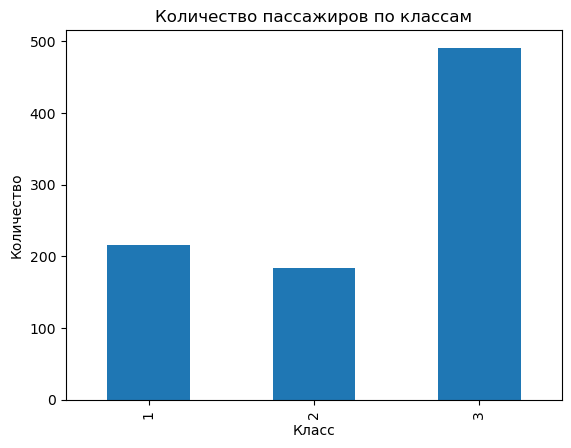

In [22]:
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

выживаемость по полу

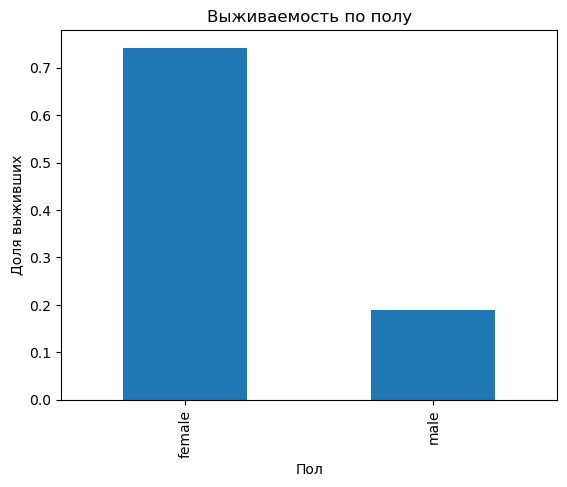

In [23]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.show()

собственный вопрос: влиял ли размер семьи на выживаемость?

ответ: одиночки и пассажиры с семьёй 2–4 человека выживали чаще, чем те, кто путешествовал большими группами (5+), — у многодетных семей доля погибших заметно выше.